Using Colab cache for faster access to the 'world-happiness-2015-2024' dataset.
Path to dataset files: /kaggle/input/world-happiness-2015-2024
Files: ['world_happiness_2018.csv', 'world_happiness_2023.csv', 'world_happiness_2022.csv', 'world_happiness_2016.csv', 'world_happiness_2015.csv', 'Readme.txt', 'world_happiness_2017.csv', 'world_happiness_2019.csv', 'world_happiness_2020.csv', 'world_happiness_2021.csv', 'world_happiness_2024.csv', 'world_happiness_combined.csv']

CSV files: ['world_happiness_2018.csv', 'world_happiness_2023.csv', 'world_happiness_2022.csv', 'world_happiness_2016.csv', 'world_happiness_2015.csv', 'world_happiness_2017.csv', 'world_happiness_2019.csv', 'world_happiness_2020.csv', 'world_happiness_2021.csv', 'world_happiness_2024.csv', 'world_happiness_combined.csv']

Columns:
Index(['Ranking', 'Country', 'Regional indicator', 'Happiness score',
       'GDP per capita', 'Social support', 'Healthy life expectancy',
       'Freedom to make life choices', 'Generosi

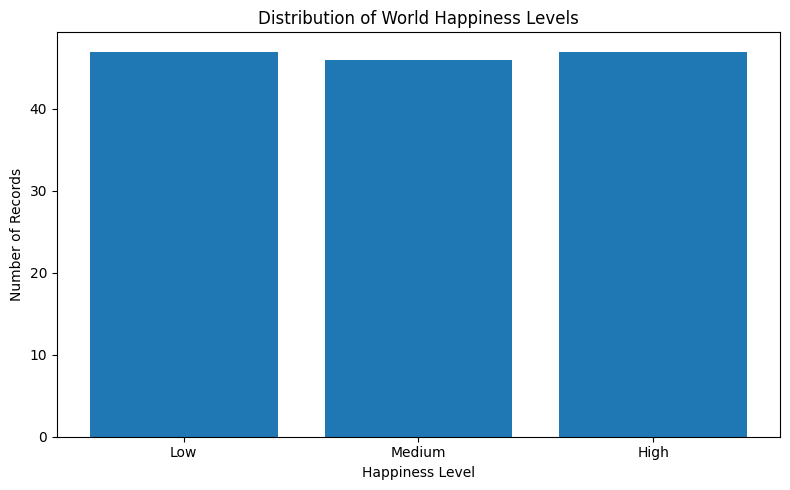

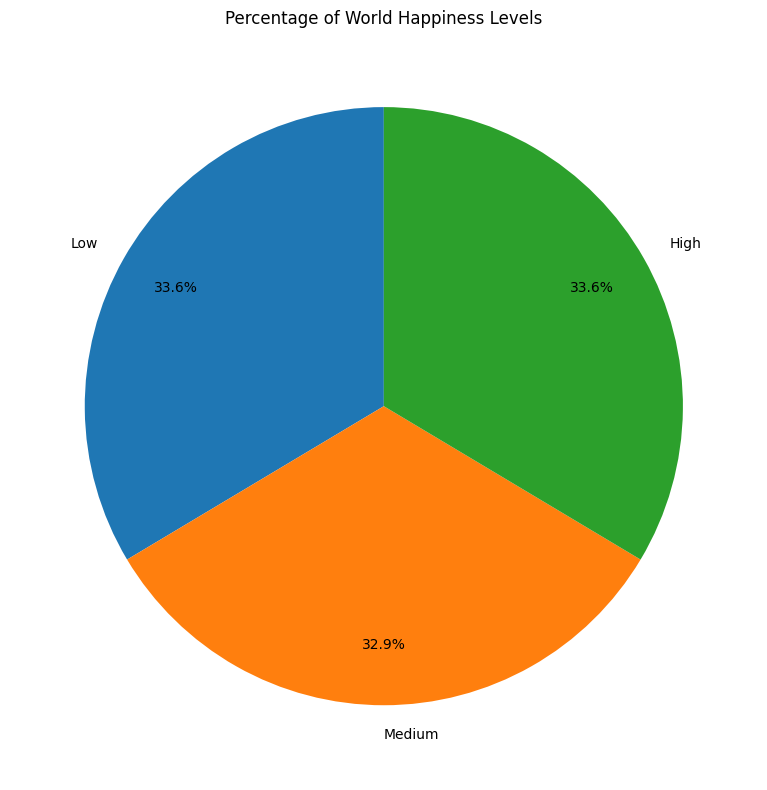

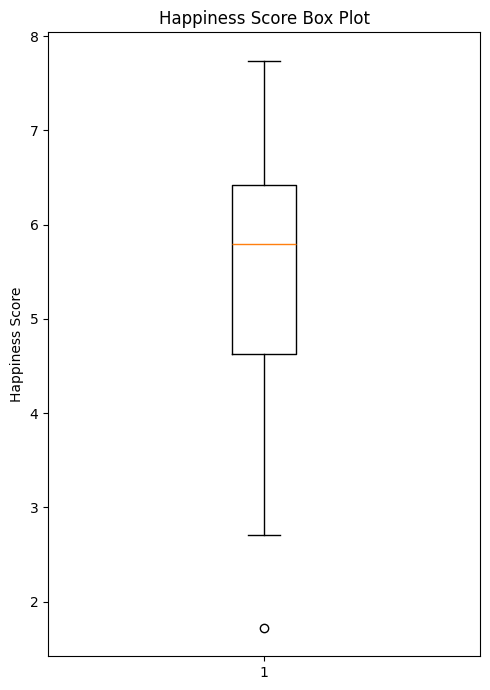

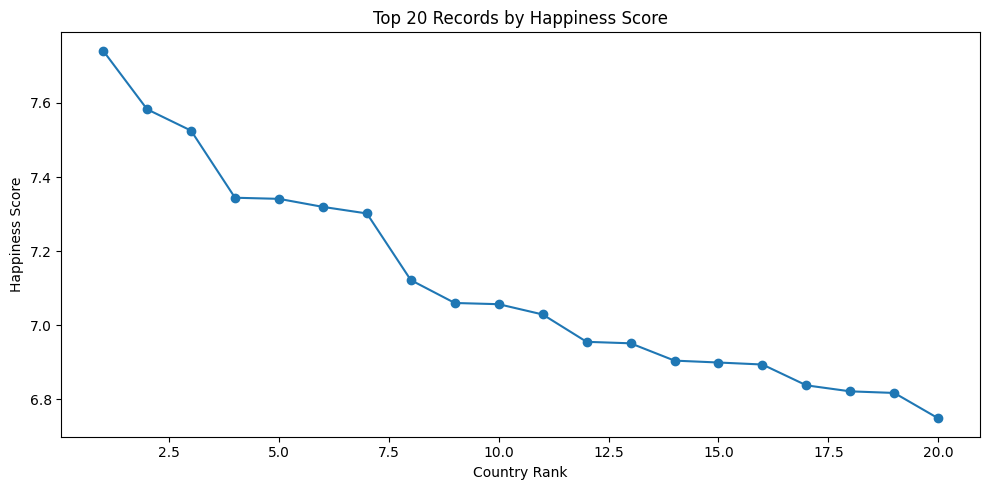

In [8]:
# ============================================================
# DVT EXPERIMENT 5
# DATA VISUALIZATION
# WORLD HAPPINESS DATASET 2015-2024
# ============================================================


# ============================================================
# CELL 1 - DOWNLOAD DATASET DIRECTLY FROM KAGGLE
# ============================================================

!pip install -q kagglehub

import kagglehub
import pandas as pd
import os
import matplotlib.pyplot as plt


# Download dataset
path = kagglehub.dataset_download(
    "yadiraespinoza/world-happiness-2015-2024"
)

print("Path to dataset files:", path)


# ============================================================
# CELL 2 - READ DATASET
# ============================================================

files = os.listdir(path)

print("Files:", files)


# Find CSV files
csv_files = [
    file for file in files
    if file.endswith(".csv")
]

print("\nCSV files:", csv_files)


# Read and combine all CSV files
dataframes = []

for file in csv_files:

    csv_path = os.path.join(path, file)

    temp = pd.read_csv(csv_path, delimiter=';') # Added delimiter parameter

    # Keep source/year information
    temp["Year_File"] = file

    dataframes.append(temp)


df = pd.concat(
    dataframes,
    ignore_index=True
)

# Convert numeric columns with comma decimals to float
for col in df.columns:
    # Check if the column is of object type (likely strings)
    if df[col].dtype == 'object':
        # Check if any value in the column contains a comma
        if df[col].astype(str).str.contains(',').any():
            try:
                # Replace comma with dot and convert to numeric
                df[col] = df[col].astype(str).str.replace(',', '.', regex=False).astype(float)
            except ValueError:
                # If conversion fails, it's not a numeric column with comma decimals
                pass


print("\nColumns:")
print(df.columns)

print("\nFirst 5 rows:")
print(df.head())


# ============================================================
# FIND HAPPINESS SCORE COLUMN
# ============================================================

if "Life Ladder" in df.columns:

    score_column = "Life Ladder"

elif "Ladder score" in df.columns:

    score_column = "Ladder score"

elif "Happiness Score" in df.columns:

    score_column = "Happiness Score"

else:

    raise ValueError(
        "Happiness score column not found."
    )


print("\nHappiness Score Column:", score_column)


# ============================================================
# FIND COUNTRY COLUMN
# ============================================================

if "Country name" in df.columns:

    country_column = "Country name"

elif "Country" in df.columns:

    country_column = "Country"

else:

    raise ValueError(
        "Country column not found."
    )


print("Country Column:", country_column)


# ============================================================
# CELL 3 - BAR CHART
# DISTRIBUTION OF HAPPINESS LEVELS
# ============================================================

# Divide happiness scores into 3 levels

df["Happiness_Level"] = pd.qcut(
    df[score_column],
    q=3,
    labels=["Low", "Medium", "High"]
)


happiness = df["Happiness_Level"].value_counts()

# Keep order
happiness = happiness.reindex(
    ["Low", "Medium", "High"]
)


plt.figure(figsize=(8,5))

plt.bar(
    happiness.index,
    happiness.values
)

plt.xlabel("Happiness Level")
plt.ylabel("Number of Records")

plt.title(
    "Distribution of World Happiness Levels"
)

plt.tight_layout()
plt.show()


# ============================================================
# CELL 4 - PIE CHART
# PERCENTAGE OF HAPPINESS LEVELS
# ============================================================

plt.figure(figsize=(8,8))

plt.pie(
    happiness.values,
    labels=happiness.index,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.8
)

plt.title(
    "Percentage of World Happiness Levels"
)

plt.tight_layout()
plt.show()


# ============================================================
# CELL 5 - BOX PLOT
# HAPPINESS SCORE DISTRIBUTION
# ============================================================

plt.figure(figsize=(5,7))

plt.boxplot(
    df[score_column].dropna()
)

plt.title(
    "Happiness Score Box Plot"
)

plt.ylabel(
    "Happiness Score"
)

plt.tight_layout()
plt.show()


# ============================================================
# CELL 6 - LINE PLOT
# TOP 20 HAPPIEST RECORDS
# ============================================================

top = df.nlargest(
    20,
    score_column
)


plt.figure(figsize=(10,5))

plt.plot(
    range(1, len(top) + 1),
    top[score_column],
    marker="o"
)

plt.xlabel(
    "Country Rank"
)

plt.ylabel(
    "Happiness Score"
)

plt.title(
    "Top 20 Records by Happiness Score"
)

plt.tight_layout()
plt.show()